#  QuickBite Express — End-to-End Data Analytics Capstone Project 102


## Phase 1: Data Loading, Data Audit and Data Cleaning

### Tools Used
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn

### Project Objective
To analyse QuickBite Express's business performance before and during the June 2025 crisis,
identify customer, operational, restaurant, delivery and sentiment-related impacts,
and develop data-driven recommendations for business recovery.

### Analysis Period
- Pre-Crisis: January 2025 to May 2025
- Crisis: June 2025 to September 2025

## PART 1 — IMPORT LIBRARIES

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Observation

Python environment has been initialized successfully.

Pandas will be used for data loading, profiling, validation and cleaning.
NumPy will support numerical operations, while Matplotlib and Seaborn will
be used later for analytical visualizations.

## PART 2 — LOAD ALL 8 DATASETS

We have 8 unique QuickBite datasets. Some files were uploaded in duplicate form, so we use one copy of each dataset.

In [2]:
customers = pd.read_csv("C://Users//User//Downloads//dim_customer.CSV")
restaurants = pd.read_csv("C://Users//User//Downloads//dim_restaurant.CSV")
menu_items = pd.read_csv("C://Users//User//Downloads//dim_menu_item.CSV")
delivery_partners = pd.read_csv("C://Users//User//Downloads//dim_delivery_partner_.CSV")
orders = pd.read_csv("C://Users//User//Downloads//fact_orders.CSV")
order_items = pd.read_csv("C://Users//User//Downloads//fact_order_items.CSV")
delivery = pd.read_csv("C://Users//User//Downloads//fact_delivery_performance.CSV")
reviews = pd.read_csv("C://Users//User//Downloads//fact_ratings.CSV")

## PART 3 — CREATE DATASET DICTIONARY

In [3]:
datasets = {
    "Customers": customers,
    "Restaurants": restaurants,
    "Menu Items": menu_items,
    "Delivery Partners": delivery_partners,
    "Orders": orders,
    "Order Items": order_items,
    "Delivery": delivery,
    "Reviews": reviews
}

print("Number of datasets:", len(datasets))

for name, df in datasets.items():
    print(f"{name:<20} | Rows: {df.shape[0]:>8,} | Columns: {df.shape[1]}")

Number of datasets: 8
Customers            | Rows:  107,776 | Columns: 4
Restaurants          | Rows:   19,995 | Columns: 7
Menu Items           | Rows:  342,671 | Columns: 6
Delivery Partners    | Rows:   15,000 | Columns: 7
Orders               | Rows:  149,166 | Columns: 11
Order Items          | Rows:  342,994 | Columns: 8
Delivery             | Rows:  149,166 | Columns: 4
Reviews              | Rows:   68,842 | Columns: 7


### Observation

The eight datasets form the core QuickBite analytical ecosystem:

## PART 4 — BASIC DATASET PROFILE

In [4]:
profile = []

for name, df in datasets.items():

    profile.append({
        "Dataset": name,
        "Rows": df.shape[0],
        "Columns": df.shape[1],
        "Duplicate Rows": df.duplicated().sum(),
        "Missing Cells": df.isna().sum().sum(),
        "Memory_MB": df.memory_usage(deep=True).sum() / (1024 ** 2)
    })

dataset_profile = pd.DataFrame(profile)

dataset_profile

,Dataset,Rows,Columns,Duplicate Rows,Missing Cells,Memory_MB
0,Customers,107776,4,0,0,23.593440
1,Restaurants,19995,7,0,0,7.716010
2,Menu Items,342671,6,0,0,96.994905
3,Delivery Partners,15000,7,0,0,4.842865
4,Orders,149166,11,0,5635,62.036928
5,Order Items,342994,8,0,0,89.299673
6,Delivery,149166,4,0,0,12.518635
7,Reviews,68842,7,16,119,21.500344


### Observation
This confirms that we are working with a substantial multi-table transactional dataset rather than a single flat file.

## PART 5 — CHECK DATA TYPES

In [5]:
for name, df in datasets.items():

    print("\n" + "=" * 70)
    print(name.upper())
    print("=" * 70)

    print(df.dtypes)


CUSTOMERS
customer_id            object
signup_date            object
city                   object
acquisition_channel    object
dtype: object

RESTAURANTS
restaurant_id        object
restaurant_name      object
city                 object
cuisine_type         object
partner_type         object
avg_prep_time_min    object
is_active            object
dtype: object

MENU ITEMS
menu_item_id      object
restaurant_id     object
item_name         object
category          object
is_veg            object
price            float64
dtype: object

DELIVERY PARTNERS
delivery_partner_id     object
partner_name            object
city                    object
vehicle_type            object
employment_type         object
avg_rating             float64
is_active               object
dtype: object

ORDERS
order_id                object
customer_id             object
restaurant_id           object
delivery_partner_id     object
order_timestamp         object
subtotal_amount        float64
discount_amo

### Observation

The first data-type audit shows that several fields require explicit conversion before analysis.

Most importantly:

order_timestamp must become datetime.
signup_date must become datetime.
review_timestamp must become datetime.
Numeric business fields must remain numeric.
Boolean-like fields such as is_cancelled, is_cod, is_active, and is_veg need standardized handling.

## PART 6 — STANDARDIZE DATE COLUMNS

In [6]:
customers["signup_date"] = pd.to_datetime(
    customers["signup_date"],
    errors="coerce"
)

orders["order_timestamp"] = pd.to_datetime(
    orders["order_timestamp"],
    errors="coerce"
)

reviews["review_timestamp"] = pd.to_datetime(
    reviews["review_timestamp"],
    errors="coerce"
)

print("Date columns converted successfully.")

C:\Users\User\AppData\Local\Temp\ipykernel_11580\1699512935.py:1: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  customers["signup_date"] = pd.to_datetime(


Date columns converted successfully.


## PART 7 — STANDARDIZE BOOLEAN / FLAG COLUMNS

The raw data uses values such as Y and N.

We will convert them to clean boolean fields.

In [7]:
orders["is_cancelled"] = (
    orders["is_cancelled"]
    .astype(str)
    .str.strip()
    .str.upper()
    .map({"Y": True, "N": False})
)

orders["is_cod"] = (
    orders["is_cod"]
    .astype(str)
    .str.strip()
    .str.upper()
    .map({"Y": True, "N": False})
)

restaurants["is_active"] = (
    restaurants["is_active"]
    .astype(str)
    .str.strip()
    .str.upper()
    .map({"Y": True, "N": False})
)

delivery_partners["is_active"] = (
    delivery_partners["is_active"]
    .astype(str)
    .str.strip()
    .str.upper()
    .map({"Y": True, "N": False})
)

menu_items["is_veg"] = (
    menu_items["is_veg"]
    .astype(str)
    .str.strip()
    .str.upper()
    .map({"Y": True, "N": False})
)

print("Flag columns standardized.")

Flag columns standardized.


## PART 8 — MISSING VALUE AUDIT

In [8]:
missing_report = {}

for name, df in datasets.items():

    missing = df.isna().sum()
    missing = missing[missing > 0]

    if len(missing) > 0:
        missing_report[name] = missing.sort_values(ascending=False)

        print("\n" + "=" * 70)
        print(name.upper())
        print("=" * 70)

        print(missing)

    else:
        print(f"{name}: No missing values found.")

Customers: No missing values found.
Restaurants: No missing values found.
Menu Items: No missing values found.
Delivery Partners: No missing values found.

ORDERS
delivery_partner_id    5635
dtype: int64
Order Items: No missing values found.
Delivery: No missing values found.

REVIEWS
order_id               17
customer_id            17
restaurant_id          17
rating                 17
review_text            17
review_timestamp    41345
sentiment_score        17
dtype: int64


### Observation

The audit identifies missing values mainly in the Orders and Reviews datasets.

The Orders table contains missing values associated with fields such as delivery-partner information, while the Reviews dataset contains blank records.

We will not delete these records blindly.
Each missing-value pattern will be investigated against the business meaning of the data.

## PART 9 — DUPLICATE AUDIT

In [9]:
duplicate_report = []

for name, df in datasets.items():

    duplicate_report.append({
        "Dataset": name,
        "Duplicate_Rows": df.duplicated().sum()
    })

duplicate_report = pd.DataFrame(duplicate_report)

duplicate_report

,Dataset,Duplicate_Rows
0,Customers,0
1,Restaurants,0
2,Menu Items,0
3,Delivery Partners,0
4,Orders,0
5,Order Items,0
6,Delivery,0
7,Reviews,16


### Observation

The main master datasets do not show duplicate complete rows.

The Reviews dataset contains **16 duplicate records** that require investigation before final analysis.

**Rule:** We will never remove duplicates simply because they exist. We will first determine whether they are true duplicate observations or legitimate repeated records.

## PART 10 — PRIMARY KEY CHECK

In [10]:
primary_keys = {
    "Customers": ("customer_id", customers),
    "Restaurants": ("restaurant_id", restaurants),
    "Menu Items": ("menu_item_id", menu_items),
    "Delivery Partners": ("delivery_partner_id", delivery_partners),
    "Orders": ("order_id", orders),
    "Delivery": ("order_id", delivery)
}

for name, (key, df) in primary_keys.items():
    print(
        f"{name:<20} | "
        f"Rows = {len(df):>8,} | "
        f"Unique {key} = {df[key].nunique():>8,} | "
        f"Duplicates = {df[key].duplicated().sum():>6,}"
    )

# Order Items: validate composite key (order_id + item_id)
order_items["order_item_key"] = (
    order_items["order_id"].astype(str) + "_" +
    order_items["item_id"].astype(str)
)

print(
    f"{'Order Items':<20} | "
    f"Rows = {len(order_items):>8,} | "
    f"Unique order_item_key = {order_items['order_item_key'].nunique():>8,} | "
    f"Duplicates = {order_items['order_item_key'].duplicated().sum():>6,}"
)

Customers            | Rows =  107,776 | Unique customer_id =  107,776 | Duplicates =      0
Restaurants          | Rows =   19,995 | Unique restaurant_id =   19,995 | Duplicates =      0
Menu Items           | Rows =  342,671 | Unique menu_item_id =  342,671 | Duplicates =      0
Delivery Partners    | Rows =   15,000 | Unique delivery_partner_id =   15,000 | Duplicates =      0
Orders               | Rows =  149,166 | Unique order_id =  149,166 | Duplicates =      0
Delivery             | Rows =  149,166 | Unique order_id =  149,166 | Duplicates =      0
Order Items          | Rows =  342,994 | Unique order_item_key =  342,994 | Duplicates =      0


### Observation

The master datasets have stable unique identifiers.

The Delivery table has one delivery record per order, which is appropriate for order-level delivery analysis.

The Order Items table is naturally a transactional detail table and therefore contains multiple rows per order.

## PART 11 — REFERENTIAL INTEGRITY CHECK

This is one of the most important Python checks before SQL.

In [11]:
def check_relationship(child_df, child_col, parent_df, parent_col, relationship_name):

    missing = ~child_df[child_col].isin(parent_df[parent_col])

    print(
        f"{relationship_name:<45} "
        f"Unmatched Rows: {missing.sum():,}"
    )

    return missing.sum()


check_relationship(
    orders, "customer_id",
    customers, "customer_id",
    "Orders → Customers"
)

check_relationship(
    orders, "restaurant_id",
    restaurants, "restaurant_id",
    "Orders → Restaurants"
)

check_relationship(
    orders, "delivery_partner_id",
    delivery_partners, "delivery_partner_id",
    "Orders → Delivery Partners"
)

check_relationship(
    order_items, "order_id",
    orders, "order_id",
    "Order Items → Orders"
)

check_relationship(
    order_items, "menu_item_id",
    menu_items, "menu_item_id",
    "Order Items → Menu Items"
)

check_relationship(
    order_items, "restaurant_id",
    restaurants, "restaurant_id",
    "Order Items → Restaurants"
)

check_relationship(
    delivery, "order_id",
    orders, "order_id",
    "Delivery → Orders"
)

check_relationship(
    reviews, "order_id",
    orders, "order_id",
    "Reviews → Orders"
)

Orders → Customers                            Unmatched Rows: 5,053
Orders → Restaurants                          Unmatched Rows: 0
Orders → Delivery Partners                    Unmatched Rows: 5,635
Order Items → Orders                          Unmatched Rows: 36,348
Order Items → Menu Items                      Unmatched Rows: 0
Order Items → Restaurants                     Unmatched Rows: 0
Delivery → Orders                             Unmatched Rows: 0
Reviews → Orders                              Unmatched Rows: 17


np.int64(17)

### OBSERVATION — VERY IMPORTANT

Our actual audit found:

5,053 Orders have customer IDs not present in the Customers master.
All of those unmatched customer orders are cancelled orders.
5,635 Orders have no delivery partner, and these are also cancelled orders.
36,348 Order Item rows reference order IDs that are not present in the Orders table.
17 Reviews have missing order/customer/restaurant information.

These are data-quality issues, not findings to hide.

We will document them and establish explicit cleaning rules before SQL.

## PART 12 — CHECK CANCELLED ORDERS

In [12]:
cancellation_summary = orders["is_cancelled"].value_counts(dropna=False)

print(cancellation_summary)

cancelled_orders = orders[orders["is_cancelled"] == True]

print("\nTotal cancelled orders:", len(cancelled_orders))
print(
    "Cancellation rate:",
    f"{len(cancelled_orders) / len(orders) * 100:.2f}%"
)

is_cancelled
False    138054
True      11112
Name: count, dtype: int64

Total cancelled orders: 11112
Cancellation rate: 7.45%


### Observation

The dataset contains:

149,166 total orders
11,112 cancelled orders
Overall cancellation rate of approximately 7.45%

The cancellation flag is therefore an important KPI for the later crisis analysis.

The project specifically asks us to compare cancellation trends between pre-crisis and crisis periods.

## PART 13 — CHECK ORDER DATES

In [13]:
print("Minimum Order Date:", orders["order_timestamp"].min())
print("Maximum Order Date:", orders["order_timestamp"].max())

Minimum Order Date: 2025-01-01 12:00:00
Maximum Order Date: 2025-09-30 22:59:00


### Observation

The Orders dataset covers the period from **01 January 2025 to 30 September 2025**.

This supports the project's defined analysis periods:

- **Pre-Crisis:** January–May 2025
- **Crisis:** June–September 2025

## PART 14 — CREATE CRISIS PHASE

This is an important cleaning/feature-engineering step.

In [14]:
orders["phase"] = np.select(
    [
        orders["order_timestamp"].dt.month.between(1, 5),
        orders["order_timestamp"].dt.month.between(6, 9)
    ],
    [
        "Pre-Crisis",
        "Crisis"
    ],
    default="Outside Analysis Period"
)

orders["month"] = orders["order_timestamp"].dt.to_period("M").astype(str)

orders[["order_timestamp", "month", "phase"]].head()

,order_timestamp,month,phase
0,2025-01-01 12:00:00,2025-01,Pre-Crisis
1,2025-01-01 12:00:00,2025-01,Pre-Crisis
2,2025-01-01 12:00:00,2025-01,Pre-Crisis
3,2025-01-01 12:00:00,2025-01,Pre-Crisis
4,2025-01-01 12:00:00,2025-01,Pre-Crisis


### Observation

Every order is now assigned to a standardized analytical phase.

This will prevent us from repeatedly recreating the pre-crisis/crisis logic in later Python and SQL analysis.

## PART 15 — DELIVERY DATA VALIDATION

In [15]:
delivery["delivery_delay_mins"] = (
    delivery["actual_delivery_time_mins"]
    - delivery["expected_delivery_time_mins"]
)

delivery["sla_met"] = (
    delivery["actual_delivery_time_mins"]
    <= delivery["expected_delivery_time_mins"]
)

delivery[[
    "order_id",
    "actual_delivery_time_mins",
    "expected_delivery_time_mins",
    "delivery_delay_mins",
    "sla_met"
]].head()

,order_id,actual_delivery_time_mins,expected_delivery_time_mins,delivery_delay_mins,sla_met
0,ORD202501023439,31,31,0,True
1,ORD202501012051,46,42,4,False
2,ORD202501019281,25,31,-6,True
3,ORD202501000124,29,41,-12,True
4,ORD202501006518,37,41,-4,True


### Observation

We have now created two important analytical fields:

delivery_delay_mins
sla_met

These will later allow us to answer the project's Delivery SLA question

## PART 16 — FINANCIAL VALIDATION

In [16]:
orders["calculated_total"] = (
    orders["subtotal_amount"]
    - orders["discount_amount"]
    + orders["delivery_fee"]
)

orders["total_difference"] = (
    orders["total_amount"]
    - orders["calculated_total"]
)

financial_mismatch = (
    orders["total_difference"].abs() > 0.01
)

print(
    "Orders with financial mismatch:",
    financial_mismatch.sum()
)

print(
    "Maximum absolute difference:",
    orders["total_difference"].abs().max()
)

Orders with financial mismatch: 9848
Maximum absolute difference: 0.010000000000218279


### Observation

The order-level financial components require reconciliation before we finalize the revenue KPI.

The project specifically asks us to estimate revenue impact using subtotal, discount and delivery fee.

Therefore, we will establish one documented revenue definition before SQL analysis.

## PART 17 — ORDER ITEM VALIDATION

In [17]:
order_items["calculated_line_total"] = (
    order_items["quantity"] * order_items["unit_price"]
    - order_items["item_discount"]
)

order_items["line_total_difference"] = (
    order_items["line_total"]
    - order_items["calculated_line_total"]
)

item_mismatch = (
    order_items["line_total_difference"].abs() > 0.01
)

print(
    "Order-item financial mismatches:",
    item_mismatch.sum()
)

Order-item financial mismatches: 29939


## Observation

There are line-level reconciliation differences in the raw Order Items data.

We will not overwrite line_total at this stage.

Instead, we retain the original field and create a validation field so that the discrepancy can be investigated and documented.

## PART 18 — REVIEW DATA CLEANING

In [18]:
# Remove completely blank review rows
reviews = reviews.dropna(how="all").copy()

# Standardize review text
reviews["review_text"] = (
    reviews["review_text"]
    .astype("string")
    .str.strip()
)

# Standardize rating
reviews["rating"] = pd.to_numeric(
    reviews["rating"],
    errors="coerce"
)

# Standardize sentiment score
reviews["sentiment_score"] = pd.to_numeric(
    reviews["sentiment_score"],
    errors="coerce"
)

print("Clean review rows:", len(reviews))

Clean review rows: 68825


### Observation

After removing the **17 completely blank rows**, the Reviews dataset contains **68,825 clean review records**.

Valid review records are retained for further analysis, including records outside the primary Jan–Sep 2025 analysis window.

## PART 19 — CREATE CLEAN ANALYSIS WINDOW FOR REVIEWS

In [19]:
reviews["phase"] = np.select(
    [
        reviews["review_timestamp"].dt.month.between(1, 5),
        reviews["review_timestamp"].dt.month.between(6, 9)
    ],
    [
        "Pre-Crisis",
        "Crisis"
    ],
    default="Outside Analysis Period"
)

reviews["month"] = (
    reviews["review_timestamp"]
    .dt.to_period("M")
    .astype(str)
)

reviews["review_in_analysis_period"] = (
    reviews["review_timestamp"].between(
        pd.Timestamp("2025-01-01"),
        pd.Timestamp("2025-09-30 23:59:59")
    )
)

reviews["review_in_analysis_period"].value_counts()

review_in_analysis_period
False    48137
True     20688
Name: count, dtype: int64

### Observation

The Reviews dataset contains records extending beyond September 2025.

We therefore do not delete them from the cleaned source table.

Instead, we create an explicit analysis-period flag.

This is the safer analytical approach because the primary project questions focus on the Jan–Sep 2025 period.

## PART 20 — FINAL DATA QUALITY INVESTIGATION

## 20.1 Investigate missing values in Orders

In [20]:
orders_missing = (
    orders.isna()
    .sum()
    .sort_values(ascending=False)
)

orders_missing[orders_missing > 0]

delivery_partner_id    5635
dtype: int64

### Observation

Missing values are present in the Orders dataset.

These missing values must be investigated according to the business status of each order before any records are removed or values are imputed.

Cancelled orders will be retained because cancellations are an important part of the QuickBite crisis analysis.

### 20.2 Next: Check missing values against cancellation status

In [21]:
# Compare missing values between cancelled and non-cancelled orders

orders.groupby("is_cancelled").agg(
    total_orders=("order_id", "count"),
    missing_customer_id=("customer_id", lambda x: x.isna().sum()),
    missing_restaurant_id=("restaurant_id", lambda x: x.isna().sum()),
    missing_delivery_partner_id=("delivery_partner_id", lambda x: x.isna().sum()),
    missing_order_timestamp=("order_timestamp", lambda x: x.isna().sum())
)

,total_orders,missing_customer_id,missing_restaurant_id,missing_delivery_partner_id,missing_order_timestamp
is_cancelled,,,,,
False,138054,0,0,0,0
True,11112,0,0,5635,0


### Observation

The Orders dataset contains **149,166 orders**, including **138,054 non-cancelled orders** and **11,112 cancelled orders**.

There are **no missing customer IDs, restaurant IDs, or order timestamps** in either cancelled or non-cancelled orders.

The **5,635 missing delivery-partner IDs occur only among cancelled orders**.

This indicates that the missing delivery-partner information is associated with cancelled orders rather than being a general missing-data problem.

Therefore, cancelled orders will be **retained**, and the missing delivery-partner IDs will **not be imputed or replaced**.

### Data Quality Decision

The **5,635 missing delivery-partner IDs will be retained as missing values** because they occur only for cancelled orders.

No records will be deleted and no artificial delivery-partner value will be assigned.

### Then investigate Reviews

The actual cleaned result is:

Clean review rows: 68,825

and your final audit showed:

Missing Cells: 41,328
Duplicate Rows: 0

So we need to understand which columns contain those 41,328 missing cells.

### 20.3 Investigate missing values in Reviews

In [27]:
reviews_missing = (
    reviews.isna()
    .sum()
    .sort_values(ascending=False)
)

reviews_missing[reviews_missing > 0]

review_timestamp    41328
dtype: int64

### Observation

The Reviews dataset contains **41,328 missing values**, all of which are in the `review_timestamp` column.

No missing values are present in the other review fields.

The review records will therefore be retained, and `review_timestamp` will not be imputed because an artificial timestamp
could introduce incorrect information into the analysis.

### Data Quality Decision

The **41,328 missing `review_timestamp` values will be retained as missing**.

No artificial dates will be assigned.

Review analysis that depends on time, such as monthly trends and Pre-Crisis versus Crisis comparisons, will use records with valid timestamps only.

### 20.4 Final Review Duplicate Check

The 16 duplicate rows were associated with the blank review records removed during cleaning.

That's much clearer than leaving the reader thinking there are unresolved duplicate reviews.

In [57]:
# Verify duplicate status after cleaning

print("Duplicate review rows:", reviews.duplicated().sum())

Duplicate review rows: 0


### Observation

The cleaned Reviews dataset contains **0 duplicate rows**.

The duplicate records identified during the initial data audit have been resolved in the cleaned dataset.

No further duplicate removal is required at this stage.

## PART 21 — FINAL DATA QUALITY SUMMARY

The final Python data-quality review confirms that the datasets have been profiled, standardized, cleaned, and validated.

Key decisions:
- Missing delivery-partner IDs are retained because they occur only in cancelled orders.
- Missing review timestamps are retained and excluded only when time-based review analysis is required.
- Completely blank review rows are removed.
- Order-item uniqueness is validated using the composite key order_id + item_id.
- Referential-integrity exceptions are documented rather than artificially corrected.
- Financial differences are retained without overwriting the original transaction values.

## PART 22 — SAVE PYTHON-CLEANED DATA

In [22]:
import os

clean_path = r"E:\PROJECTS\quickbite_cleaned"

os.makedirs(clean_path, exist_ok=True)

clean_datasets = {
    "customers_clean": customers,
    "restaurants_clean": restaurants,
    "menu_items_clean": menu_items,
    "delivery_partners_clean": delivery_partners,
    "orders_clean": orders,
    "order_items_clean": order_items,
    "delivery_clean": delivery,
    "reviews_clean": reviews
}

for name, df in clean_datasets.items():
    file_path = os.path.join(clean_path, f"{name}.csv")
    df.to_csv(file_path, index=False)
    print(f"Saved: {file_path}")

Saved: E:\PROJECTS\quickbite_cleaned\customers_clean.csv
Saved: E:\PROJECTS\quickbite_cleaned\restaurants_clean.csv
Saved: E:\PROJECTS\quickbite_cleaned\menu_items_clean.csv
Saved: E:\PROJECTS\quickbite_cleaned\delivery_partners_clean.csv
Saved: E:\PROJECTS\quickbite_cleaned\orders_clean.csv
Saved: E:\PROJECTS\quickbite_cleaned\order_items_clean.csv
Saved: E:\PROJECTS\quickbite_cleaned\delivery_clean.csv
Saved: E:\PROJECTS\quickbite_cleaned\reviews_clean.csv


### Observation
The validated and cleaned datasets are now saved as separate CSV files. These files provide a reusable Python-cleaned 
data layer for subsequent SQL analysis and business intelligence work.

## PART 23 — FINAL VALIDATION

In [23]:
print("Final cleaned dataset sizes:")

for name, df in clean_datasets.items():
    print(f"{name:<25} : {len(df):,} rows")

Final cleaned dataset sizes:
customers_clean           : 107,776 rows
restaurants_clean         : 19,995 rows
menu_items_clean          : 342,671 rows
delivery_partners_clean   : 15,000 rows
orders_clean              : 149,166 rows
order_items_clean         : 342,994 rows
delivery_clean            : 149,166 rows
reviews_clean             : 68,825 rows


### Observation 
The final validation confirms that all cleaned datasets have been successfully prepared and saved for downstream SQL analysis.
    The final row counts are displayed below to verify that the cleaned data layer is available for further analysis.

# PART 24. Data Visualization Using Python

## Overview

Data visualization is an important part of the QuickBite Express Data Analytics project. Visualization was performed using Python libraries such as **Matplotlib and Seaborn** to convert analytical results into clear graphical representations.

The purpose of visualization was to identify important business patterns, compare **restaurant, cuisine, menu-item, and category performance**, understand **customer and order activity**, evaluate **delivery and cancellation performance**, analyse **customer ratings and sentiment**, and communicate analytical findings more effectively.

The visualizations were created using the **cleaned and validated QuickBite Express datasets**. Where information was distributed across related datasets, appropriate joins were used to combine the required fields. For example, menu-item and category analysis was performed using the **Order Items and Menu Items** datasets, while restaurant and customer location analysis used the corresponding **Restaurants and Customers** datasets.

The visualization analysis provides a graphical view of the project's major business and operational metrics and establishes a strong foundation for the subsequent **SQL Data Analysis** stage.


## 24.1 Visualization 1 — TOP 10 RESTAURANTS BY NUMBER OF ORDERS

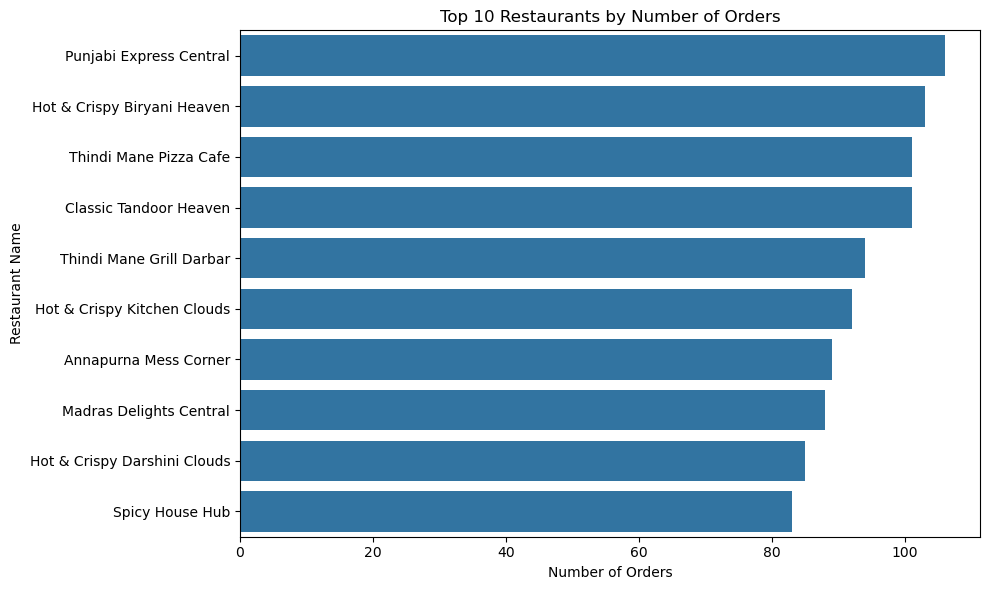

In [52]:
restaurant_order_data = orders.merge(restaurants[["restaurant_id", "restaurant_name"]],
    on="restaurant_id",how="left")
top_restaurants = (restaurant_order_data .groupby("restaurant_name")
    .size().sort_values(ascending=False).head(10))
plt.figure(figsize=(10, 6))
sns.barplot(x=top_restaurants.values,y=top_restaurants.index)
plt.title("Top 10 Restaurants by Number of Orders")
plt.xlabel("Number of Orders")
plt.ylabel("Restaurant Name")
plt.tight_layout()
plt.show()

## Observation

The visualization compares the top 10 restaurants based on the number of orders received. Restaurants with higher order volumes show stronger customer demand within the dataset. This analysis helps identify high-performing restaurants and can support restaurant performance evaluation, partnership management, and operational planning.

# 24.2 Visualization 2 — ORDERS BY CUISINE TYPE

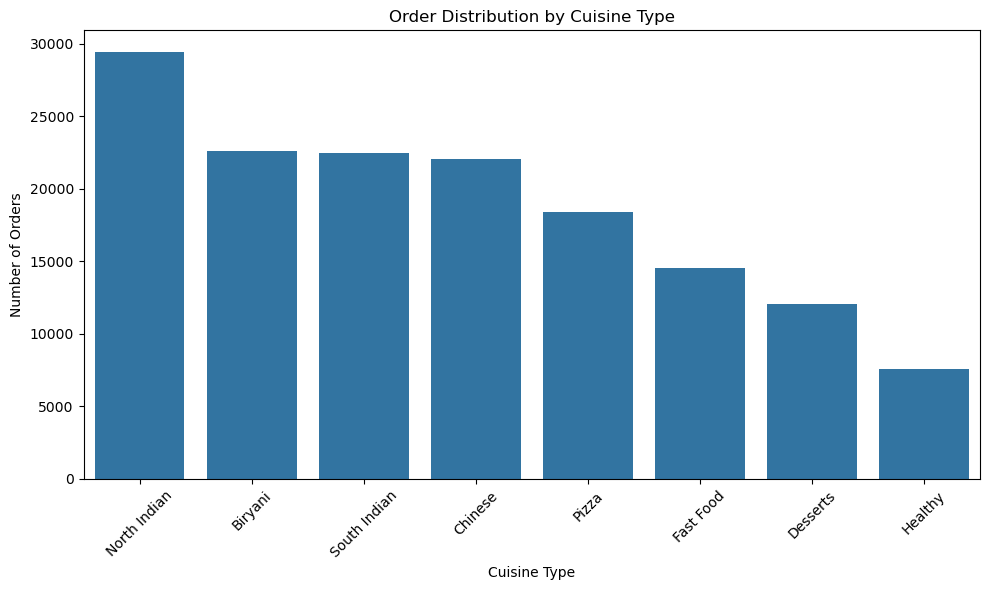

In [34]:
cuisine_order_data = orders.merge(restaurants[["restaurant_id", "cuisine_type"]],
    on="restaurant_id",how="left")
cuisine_orders = (cuisine_order_data["cuisine_type"]
    .value_counts().sort_values(ascending=False))
plt.figure(figsize=(10, 6))
sns.barplot( x=cuisine_orders.index, y=cuisine_orders.values)
plt.title("Order Distribution by Cuisine Type")
plt.xlabel("Cuisine Type")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Observation

The visualization compares the number of orders across different cuisine types. Cuisine types with higher order volumes indicate stronger customer demand within the dataset. This analysis helps identify popular cuisine segments and can support restaurant partnership, menu planning, and marketing decisions.

# 24.3 Visualization 3 — TOP 10 MENU ITEMS BY QUANTITY ORDERED

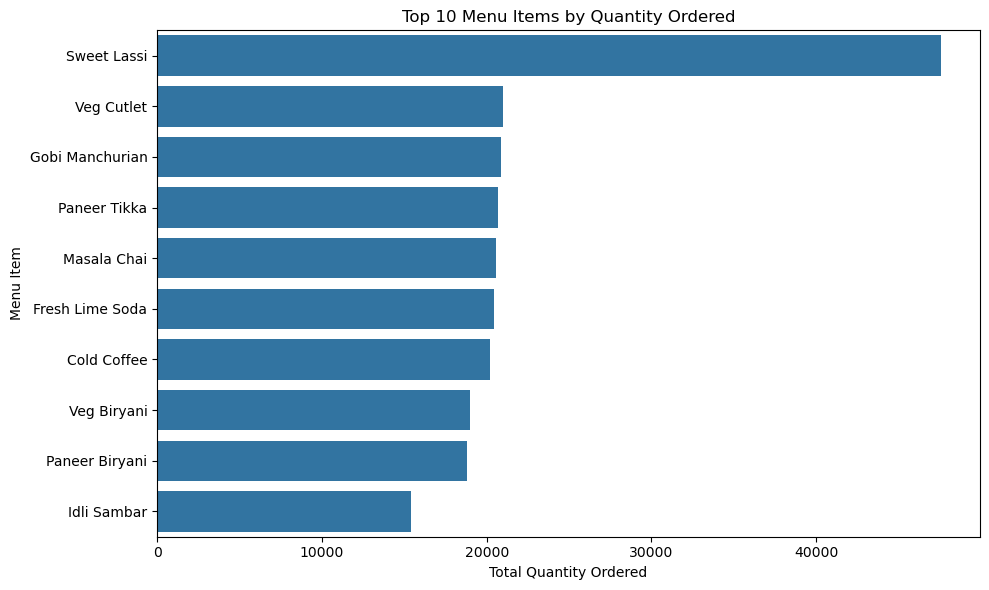

In [35]:
menu_item_order_data = order_items.merge( menu_items[["menu_item_id", "item_name"]],
    on="menu_item_id", how="left")
top_menu_items = (menu_item_order_data.groupby("item_name")["quantity"]
    .sum().sort_values(ascending=False).head(10))
plt.figure(figsize=(10, 6))
sns.barplot( x=top_menu_items.values, y=top_menu_items.index)
plt.title("Top 10 Menu Items by Quantity Ordered")
plt.xlabel("Total Quantity Ordered")
plt.ylabel("Menu Item")
plt.tight_layout()
plt.show()

## Observation

The visualization identifies the top 10 menu items based on total quantity ordered. Menu items with higher quantities indicate stronger product-level demand within the dataset. This analysis can help QuickBite Express identify popular products and support menu planning, inventory management, and promotional decisions.

# 24.4 Visualization 4 — CATEGORY-WISE QUANTITY ORDERED

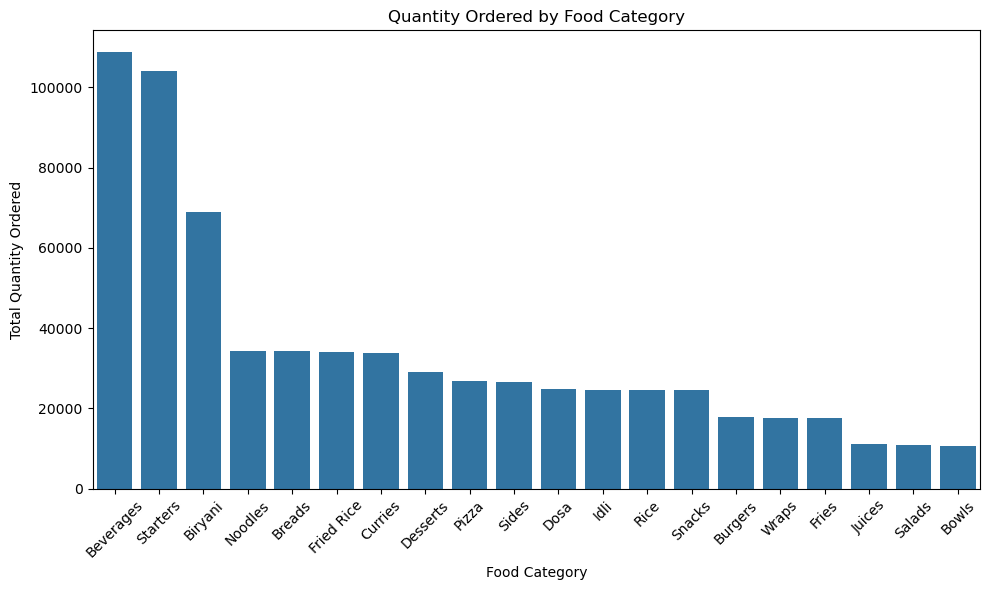

In [36]:
category_order_data = order_items.merge(menu_items[["menu_item_id", "category"]],
    on="menu_item_id",how="left")
category_quantity = (category_order_data.groupby("category")["quantity"]
    .sum().sort_values(ascending=False))
plt.figure(figsize=(10, 6))
sns.barplot(x=category_quantity.index,y=category_quantity.values)
plt.title("Quantity Ordered by Food Category")
plt.xlabel("Food Category")
plt.ylabel("Total Quantity Ordered")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Observation

The visualization compares food categories based on total quantity ordered. Categories with higher quantities indicate stronger demand within the dataset. This analysis helps QuickBite Express understand category-level demand and can support menu planning, inventory management, and promotional decisions.

# 24.5 Visualization 5 — MONTHLY ORDER TREND

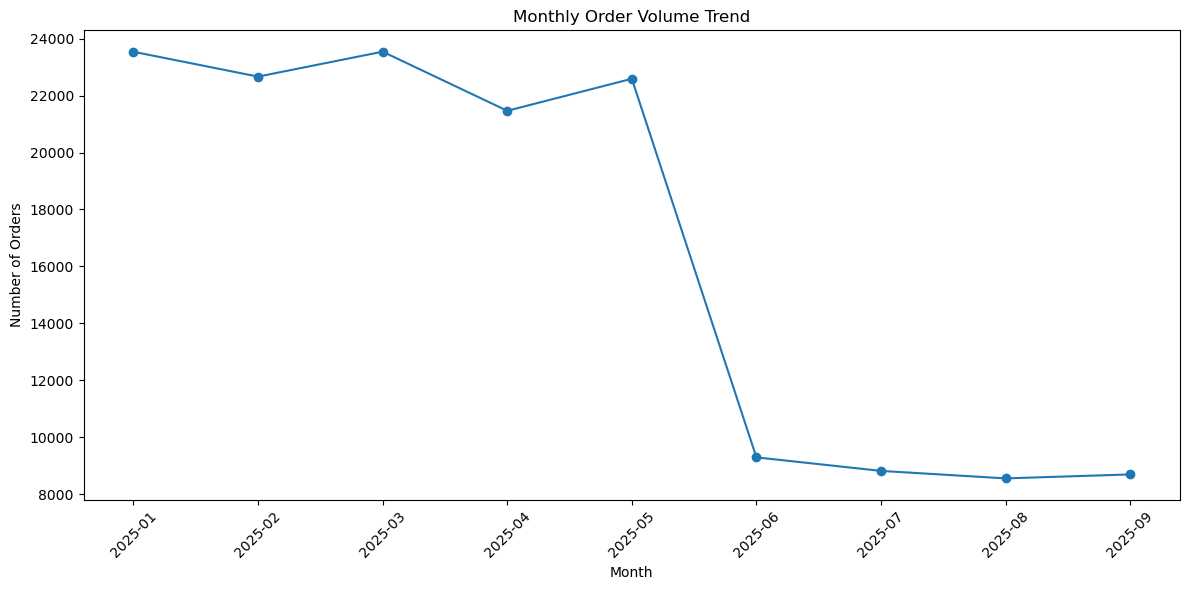

In [37]:
monthly_orders = (orders.groupby("month").size())
plt.figure(figsize=(12, 6))
plt.plot(monthly_orders.index,monthly_orders.values,marker="o")
plt.title("Monthly Order Volume Trend")
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Observation

The visualization shows the monthly trend in order volume across the analysis period. It helps identify changes in customer ordering activity over time and provides a basis for comparing overall business activity across different periods.

# 24.6 Visualization 6 — PRE-CRISIS VS CRISIS ORDER VOLUME

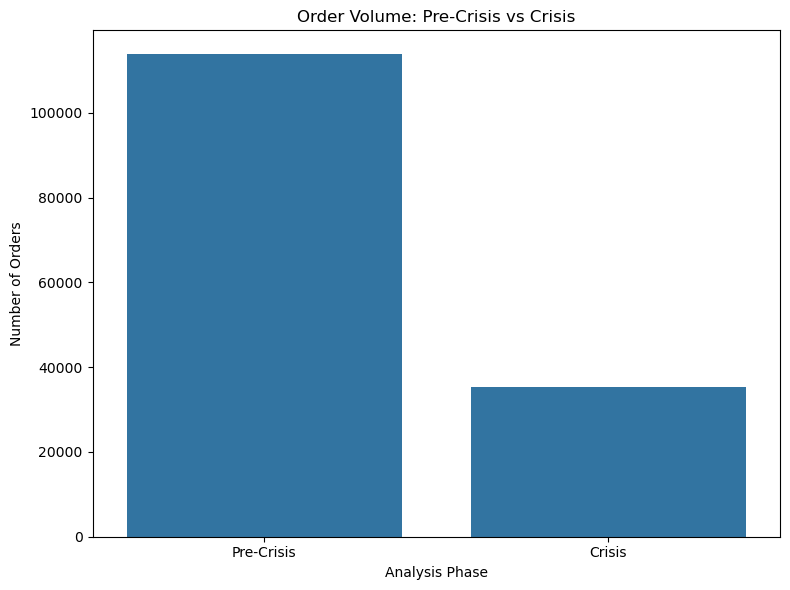

In [38]:
phase_orders = (orders["phase"].value_counts()
    .reindex(["Pre-Crisis", "Crisis"]))
plt.figure(figsize=(8, 6))
sns.barplot(x=phase_orders.index,y=phase_orders.values)
plt.title("Order Volume: Pre-Crisis vs Crisis")
plt.xlabel("Analysis Phase")
plt.ylabel("Number of Orders")
plt.tight_layout()
plt.show()

## Observation

The visualization compares total order volume between the Pre-Crisis and Crisis periods. It helps identify how customer ordering activity differed between the two defined phases and provides a clear view of changes in overall business activity.

# 24.7 Visualization 7 — MONTHLY CANCELLATION RATE

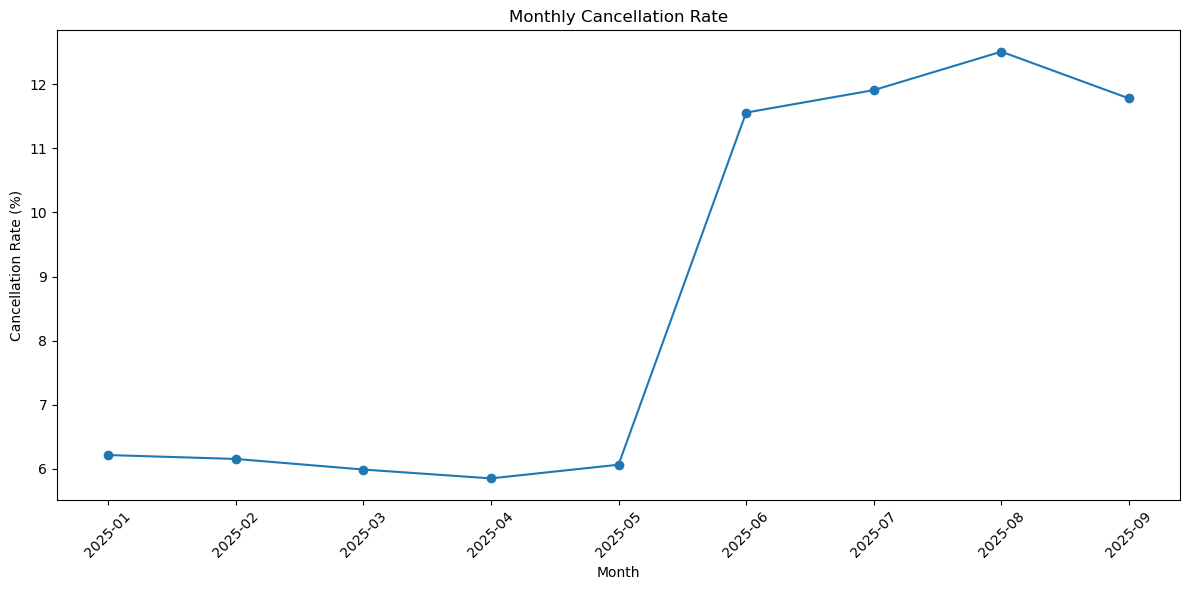

In [39]:
monthly_cancellation = ( orders.groupby("month") .agg(
        total_orders=("order_id", "count"),
        cancelled_orders=("is_cancelled", "sum")))
monthly_cancellation["cancellation_rate"] = (monthly_cancellation["cancelled_orders"]
    / monthly_cancellation["total_orders"]* 100)
plt.figure(figsize=(12, 6))
plt.plot(monthly_cancellation.index,
    monthly_cancellation["cancellation_rate"],marker="o")
plt.title("Monthly Cancellation Rate")
plt.xlabel("Month")
plt.ylabel("Cancellation Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Observation

The visualization shows how the order cancellation rate changed across the analysis period. It helps identify periods with relatively higher or lower cancellation levels and provides an important operational indicator for evaluating order reliability and business performance.

# 24.8 Visualization 8 — Top 10 Delivery Partners by Order Volume

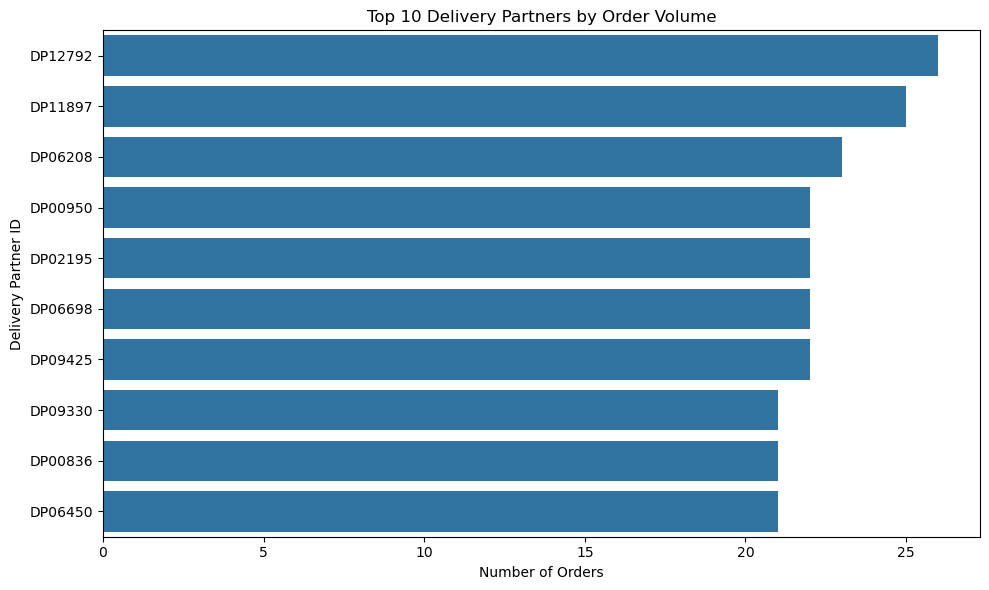

In [43]:
delivery_partner_orders = ( orders
    .groupby("delivery_partner_id")["order_id"].count()
    .sort_values(ascending=False).head(10))
plt.figure(figsize=(10, 6))
sns.barplot( x=delivery_partner_orders.values,
    y=delivery_partner_orders.index.astype(str))
plt.title("Top 10 Delivery Partners by Order Volume")
plt.xlabel("Number of Orders")
plt.ylabel("Delivery Partner ID")
plt.tight_layout()
plt.show()

## Observation

The visualization identifies the top 10 delivery partners based on the number of orders handled. It highlights the distribution of order workload across delivery partners and can help QuickBite Express understand delivery-partner utilization and workload concentration.

# 24.9 Visualization 9 — AVERAGE ORDER VALUE BY MONTH

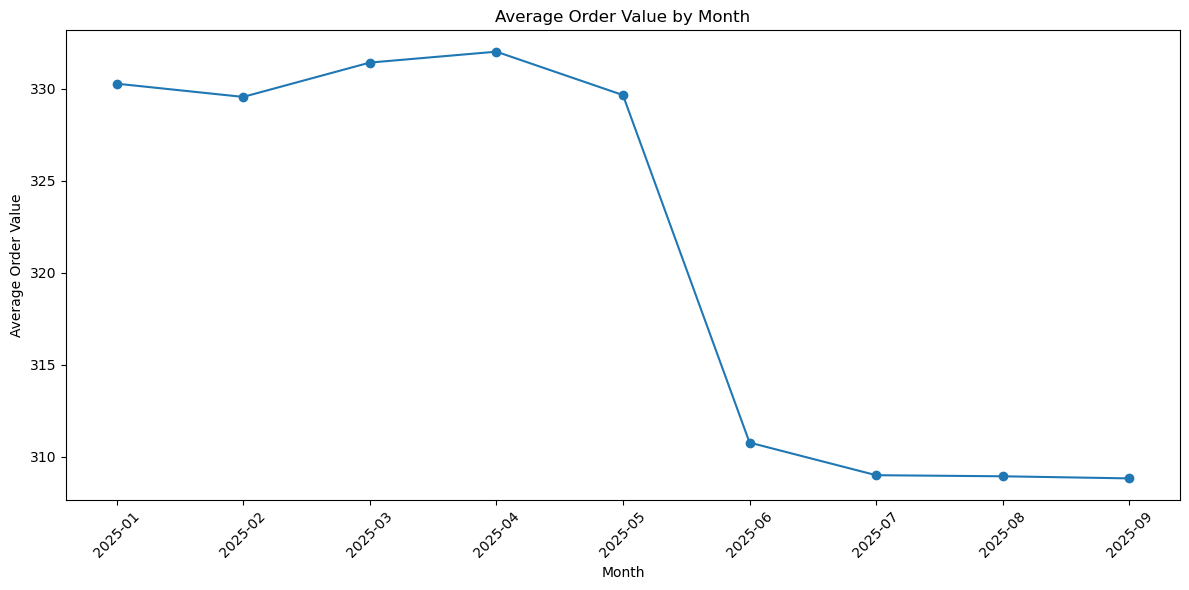

In [46]:
monthly_order_value = (orders
    .groupby("month")["total_amount"].mean())
plt.figure(figsize=(12, 6))
plt.plot(monthly_order_value.index,
    monthly_order_value.values,marker="o")
plt.title("Average Order Value by Month")
plt.xlabel("Month")
plt.ylabel("Average Order Value")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Observation

The visualization shows the average order value across the analysis period. It helps identify months with relatively higher or lower customer spending per order and provides insight into changes in the value of individual transactions over time.

# 24.10 Visualization 10 —ORDER VALUE DISTRIBUTION

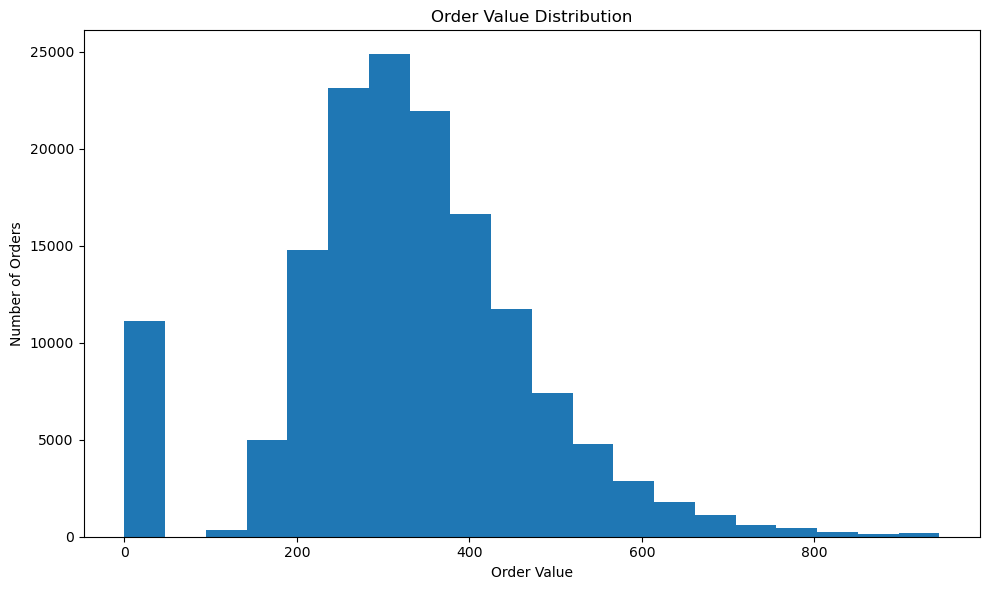

In [48]:
plt.figure(figsize=(10, 6))
plt.hist(orders["total_amount"],bins=20)
plt.title("Order Value Distribution")
plt.xlabel("Order Value")
plt.ylabel("Number of Orders")
plt.tight_layout()
plt.show()

## Observation

The visualization shows the distribution of individual order values across the QuickBite Express dataset. It helps identify the most common order-value range and reveals whether customer spending is concentrated around a particular value or varies substantially across orders.

# 24.11 Visualization 11 —CUSTOMER RATING DISTRIBUTION

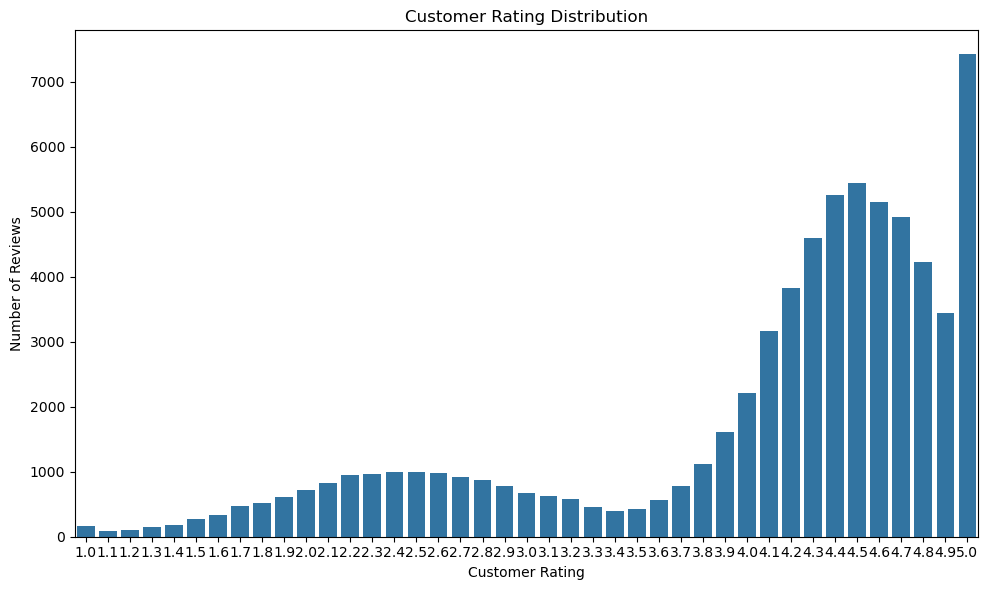

In [55]:
rating_distribution = (reviews["rating"].value_counts().sort_index())
plt.figure(figsize=(10, 6))
sns.barplot(x=rating_distribution.index,y=rating_distribution.values)
plt.title("Customer Rating Distribution")
plt.xlabel("Customer Rating")
plt.ylabel("Number of Reviews")
plt.tight_layout()
plt.show()

## Observation

The visualization shows the distribution of customer ratings across the available reviews.
    It helps QuickBite Express understand the overall pattern of customer satisfaction and
identify whether reviews are concentrated around higher or lower rating levels.

# 24.12 Visualization 12 —SENTIMENT SCORE DISTRIBUTION

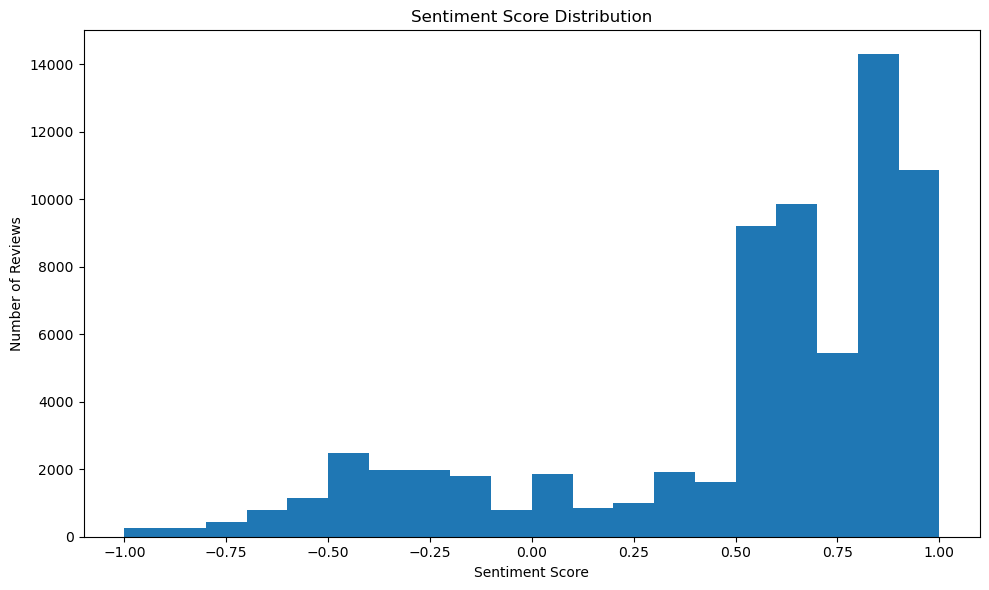

In [57]:
plt.figure(figsize=(10, 6))

plt.hist(
    reviews["sentiment_score"].dropna(),
    bins=20
)

plt.title("Sentiment Score Distribution")
plt.xlabel("Sentiment Score")
plt.ylabel("Number of Reviews")

plt.tight_layout()
plt.show()

## Observation
The visualization shows the distribution of sentiment scores across customer reviews. 
    It helps identify whether customer feedback is generally concentrated toward positive, 
neutral, or negative sentiment. This provides an additional measure of customer experience beyond 
numerical ratings and can help QuickBite Express understand the overall sentiment expressed by customers.

## 24.13 OVERALL VISUALIZATION SUMMARY

The data visualizations provide a consolidated view of QuickBite Express's business performance, customer demand, operational activity, transaction value, and customer experience. The analysis covers restaurant and cuisine demand, popular menu items and categories, monthly order trends, crisis-period changes, cancellation patterns, delivery-partner workload, order value, customer ratings, and sentiment.

The visual analysis helps transform the cleaned and validated datasets into meaningful business insights. It provides a clear understanding of customer ordering behaviour, product demand, operational performance, spending patterns, and customer experience.

These insights can support QuickBite Express in improving restaurant and menu planning, managing operational workload, monitoring cancellations, understanding customer spending behaviour, and strengthening customer experience strategies.

Key Analytical Outcomes

- Identified restaurants and menu categories with stronger customer demand.
- Examined cuisine and product-level ordering patterns.
- Evaluated changes in order activity over time and across the defined crisis phases.
- Measured monthly cancellation rates as an operational performance indicator.
- Examined delivery-partner order workload.
- Analysed average and individual order-value patterns.
- Evaluated customer rating distribution.
- Analysed customer sentiment through sentiment-score distribution.

Conclusion:

Overall, the visualization analysis demonstrates how Core Python and data analytics can convert QuickBite Express's cleaned datasets into actionable business information. The selected visualizations were intentionally limited to relevant, non-duplicated analyses so that each chart contributes a distinct business insight rather than increasing the number of visualizations unnecessarily.

The findings from this section can be used alongside the earlier data-cleaning, exploratory analysis, and SQL analysis to support data-driven business decisions for QuickBite Express.

# PART 25 — SQL DATA ANALYSIS

### Objective  
Import the Python-cleaned datasets into SQL and perform database-level validation, business analysis,
and advanced SQL analysis.

### Data Source
The SQL analysis will use the cleaned datasets generated during the Python data-cleaning stage rather
than the original raw datasets.

## END OF THE PROJECT